# Linear Regression – Wine Dataset

Predicts alcohol content from the other wine chemistry features using `ml_package`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

# Find the repo root that contains the current package
cwd = Path.cwd()
repo_root = None

# Search current folder and all parent folders
for folder in [cwd] + list(cwd.parents):
    if (folder / "ml_package").exists():
        repo_root = folder
        break

if repo_root is None:
    raise FileNotFoundError(
        "Could not find a folder named 'ml_package'. "
    )

# Add repo root to Python path
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Current working directory:", cwd)
print("Repo root found:", repo_root)
print("Package folder found:", repo_root / "ml_package")

# Import from package
from ml_package.processing.preprocessing import train_test_split, standardize
from ml_package.supervised.linear_regression import (
    LinearRegression,
    RidgeRegression,
    LassoRegression,
)

Current working directory: /Users/shrutipatankar/CMOR438-Spring2026/notebooks/supervised_learning
Repo root found: /Users/shrutipatankar/CMOR438-Spring2026
Package folder found: /Users/shrutipatankar/CMOR438-Spring2026/ml_package


## 1. Load Dataset

In [ ]:
wine = load_wine(as_frame=True)
wine_features = wine.data.copy()

target_name = "alcohol"
predictor_names = [col for col in wine_features.columns if col != target_name]

X = wine_features[predictor_names].to_numpy()
y = wine_features[target_name].to_numpy()

# Print descriptive table for dataset
wine_features.describe().T

X shape: (178, 12)
y shape: (178,)


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


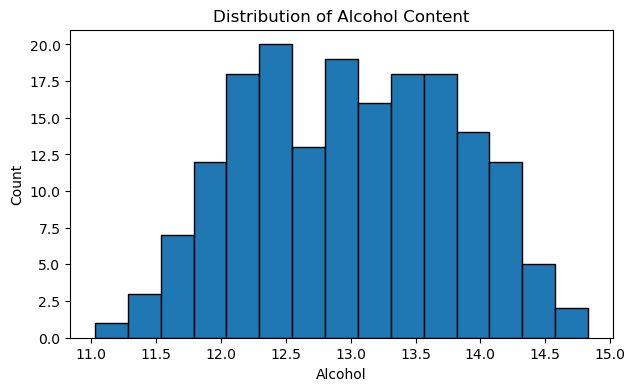

In [ ]:
# Plot a distribution of the alcohol content
plt.figure(figsize=(7, 4))
plt.hist(y, bins=15, edgecolor="black")
plt.xlabel("Alcohol")
plt.ylabel("Count")
plt.title("Distribution of Alcohol Content")
plt.show()

## 2. Exploratory Data Analysis

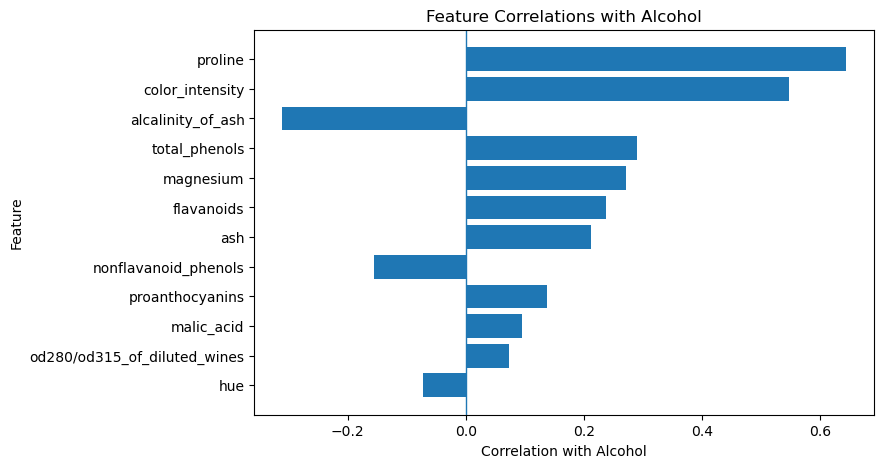

In [ ]:
# Plot correlation with alcohol content
correlations = wine_features.corr(numeric_only = True)[target_name].drop(target_name)
correlations = correlations.sort_values(key = lambda s: s.abs(), ascending = False)

plt.figure(figsize=(8, 5))
plt.barh(correlations.index, correlations.values)
plt.axvline(0, linewidth = 1)
plt.xlabel("Correlation with Alcohol")
plt.ylabel("Feature")
plt.title("Feature Correlations with Alcohol")
plt.gca().invert_yaxis()
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (142, 12) | X_test: (36, 12)


## 3. Train/Test Split

In [6]:
X_train_scaled, scaling_params = standardize(X_train, return_params=True)
X_test_scaled = standardize(
    X_test,
    mean=scaling_params["mean"],
    scale=scaling_params["scale"],
)

print("Training means after scaling:", np.round(X_train_scaled.mean(axis=0), 4))
print("Training stds after scaling: ", np.round(X_train_scaled.std(axis=0), 4))

Training means after scaling: [-0. -0.  0.  0.  0.  0. -0.  0. -0.  0.  0. -0.]
Training stds after scaling:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Standardize Features

Fit scaler on training set only to avoid data leakage.

In [7]:
def mse(y_true, y_pred):
    return float(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))

def rmse(y_true, y_pred):
    return float(np.sqrt(mse(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def r2(y_true, y_pred):
    y_true = np.asarray(y_true)
    ss_res = np.sum((y_true - np.asarray(y_pred)) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 0.0 if ss_tot == 0 else float(1 - ss_res / ss_tot)

def evaluate(model, X_train, y_train, X_test, y_test):
    tr, te = model.predict(X_train), model.predict(X_test)
    return {
        "Train MSE": mse(y_train, tr),   "Test MSE":  mse(y_test, te),
        "Train RMSE": rmse(y_train, tr), "Test RMSE": rmse(y_test, te),
        "Train MAE": mae(y_train, tr),   "Test MAE":  mae(y_test, te),
        "Train R2":  r2(y_train, tr),    "Test R2":   r2(y_test, te),
    }, tr, te

## 5. Metric Helpers

In [8]:
ols = LinearRegression(fit_intercept=True, standardize=False)
ols.fit(X_train_scaled, y_train)
ols_results, ols_train_pred, ols_test_pred = evaluate(
    ols, X_train_scaled, y_train, X_test_scaled, y_test
)
pd.DataFrame([ols_results], index=["LinearRegression"])

,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
LinearRegression,0.246283,0.356516,0.496269,0.59709,0.399601,0.468631,0.612281,0.514021


## 6. Fit OLS Linear Regression

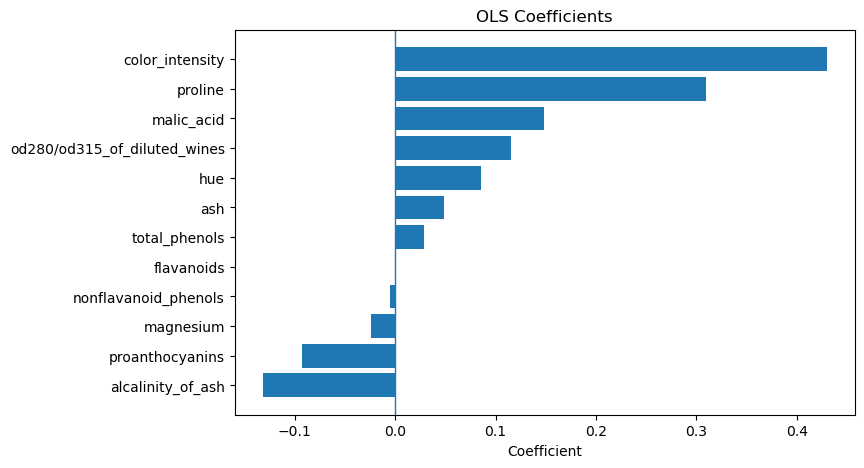

,feature,coefficient
8,color_intensity,0.429597
11,proline,0.309077
0,malic_acid,0.147870
2,alcalinity_of_ash,-0.131717
10,od280/od315_of_diluted_wines,0.115133
7,proanthocyanins,-0.092529
9,hue,0.085777
1,ash,0.048225
4,total_phenols,0.028822
3,magnesium,-0.024519


In [9]:
coef_df = pd.DataFrame({
    "feature": predictor_names,
    "coefficient": ols.coef_,
}).assign(abs_coef=lambda d: d["coefficient"].abs()).sort_values("abs_coef", ascending=False)

plt.figure(figsize=(8, 5))
plot_df = coef_df.sort_values("coefficient")
plt.barh(plot_df["feature"], plot_df["coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Coefficient")
plt.title("OLS Coefficients")
plt.show()

coef_df.drop(columns="abs_coef")

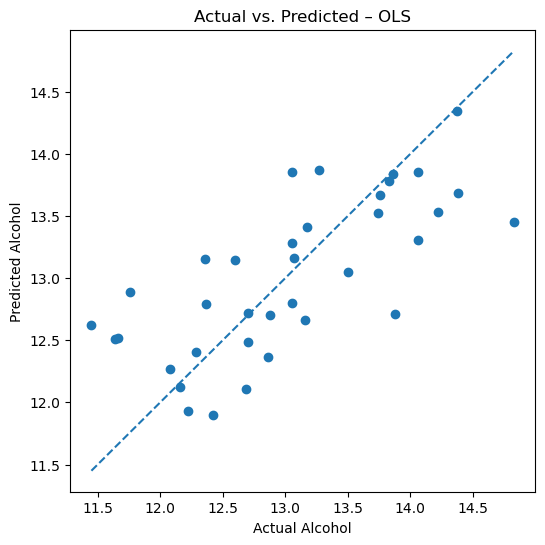

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, ols_test_pred)
lo, hi = min(y_test.min(), ols_test_pred.min()), max(y_test.max(), ols_test_pred.max())
plt.plot([lo, hi], [lo, hi], linestyle="--")
plt.xlabel("Actual Alcohol")
plt.ylabel("Predicted Alcohol")
plt.title("Actual vs. Predicted – OLS")
plt.show()

## 7. Actual vs. Predicted

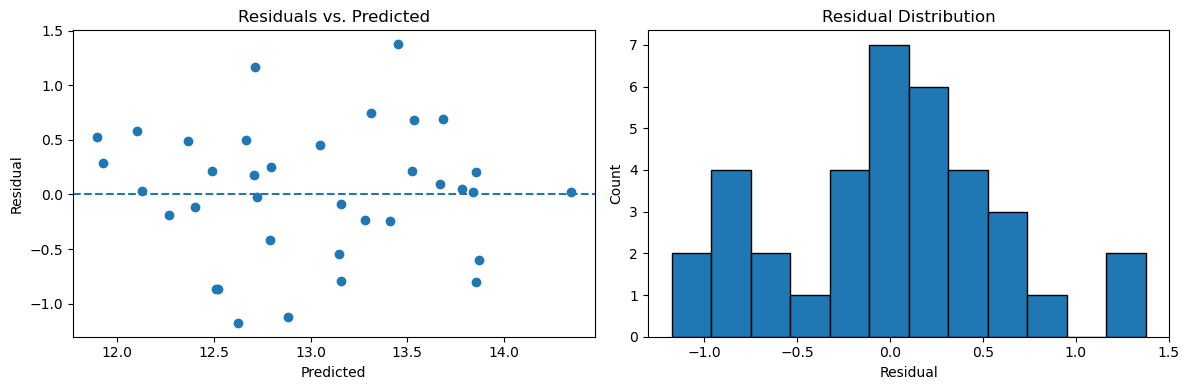

In [11]:
ols_resid = y_test - ols_test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(ols_test_pred, ols_resid)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs. Predicted")

axes[1].hist(ols_resid, bins=12, edgecolor="black")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

## 8. Residual Analysis

In [12]:
models = {
    "LinearRegression":  LinearRegression(fit_intercept=True, standardize=False),
    "Ridge_0.1":   RidgeRegression(alpha=0.1,  fit_intercept=True, standardize=False),
    "Ridge_1.0":   RidgeRegression(alpha=1.0,  fit_intercept=True, standardize=False),
    "Ridge_10.0":  RidgeRegression(alpha=10.0, fit_intercept=True, standardize=False),
    "Lasso_0.001": LassoRegression(alpha=0.001, fit_intercept=True, standardize=False, max_iter=5000),
    "Lasso_0.01":  LassoRegression(alpha=0.01,  fit_intercept=True, standardize=False, max_iter=5000),
    "Lasso_0.1":   LassoRegression(alpha=0.1,   fit_intercept=True, standardize=False, max_iter=5000),
}

rows, fitted = [], {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    results, _, _ = evaluate(model, X_train_scaled, y_train, X_test_scaled, y_test)
    row = {"Model": name, **results}
    if hasattr(model, "coef_") and model.coef_ is not None:
        row["Nonzero Coefs"] = int(np.sum(np.abs(model.coef_) > 1e-8))
    rows.append(row)
    fitted[name] = model

comparison_df = pd.DataFrame(rows).sort_values("Test RMSE").reset_index(drop=True)
comparison_df

,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,Nonzero Coefs
0,Lasso_0.01,0.248194,0.350009,0.498191,0.591616,0.401514,0.466180,0.609273,0.522892,10
1,Ridge_10.0,0.248554,0.350727,0.498552,0.592222,0.401800,0.466732,0.608707,0.521913,12
2,Ridge_1.0,0.246318,0.355444,0.496304,0.596192,0.399769,0.468488,0.612227,0.515482,12
3,Lasso_0.001,0.246304,0.355838,0.496290,0.596521,0.399652,0.468307,0.612248,0.514946,12
4,Ridge_0.1,0.246284,0.356401,0.496270,0.596994,0.399618,0.468618,0.612281,0.514178,12
5,LinearRegression,0.246283,0.356516,0.496269,0.597090,0.399601,0.468631,0.612281,0.514021,12
6,Lasso_0.1,0.295479,0.396281,0.543580,0.629508,0.436196,0.495896,0.534834,0.459817,2


## 9. Compare OLS, Ridge, and Lasso

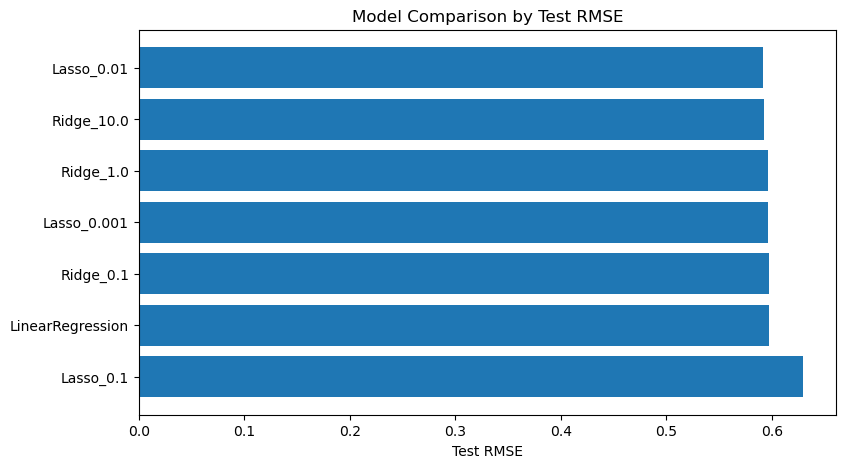

In [13]:
plt.figure(figsize=(9, 5))
plt.barh(comparison_df["Model"], comparison_df["Test RMSE"])
plt.xlabel("Test RMSE")
plt.title("Model Comparison by Test RMSE")
plt.gca().invert_yaxis()
plt.show()

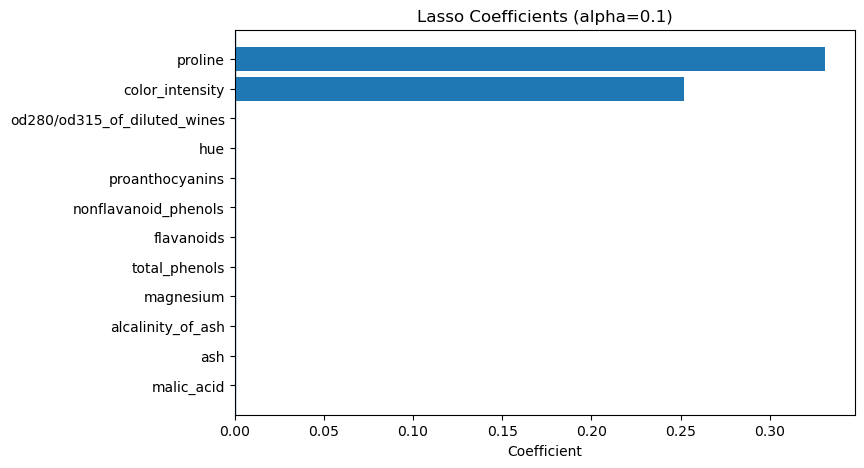

,feature,coefficient,selected
0,malic_acid,0.000000,False
1,ash,0.000000,False
2,alcalinity_of_ash,0.000000,False
3,magnesium,0.000000,False
4,total_phenols,0.000000,False
5,flavanoids,0.000000,False
6,nonflavanoid_phenols,0.000000,False
7,proanthocyanins,0.000000,False
9,hue,0.000000,False
10,od280/od315_of_diluted_wines,0.000000,False


In [14]:
lasso_model = fitted["Lasso_0.1"]
lasso_coef_df = pd.DataFrame({
    "feature": predictor_names,
    "coefficient": lasso_model.coef_,
    "selected": np.abs(lasso_model.coef_) > 1e-8,
}).sort_values("coefficient")

plt.figure(figsize=(8, 5))
plt.barh(lasso_coef_df["feature"], lasso_coef_df["coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Coefficient")
plt.title("Lasso Coefficients (alpha=0.1)")
plt.show()

lasso_coef_df

Best model: Lasso_0.01


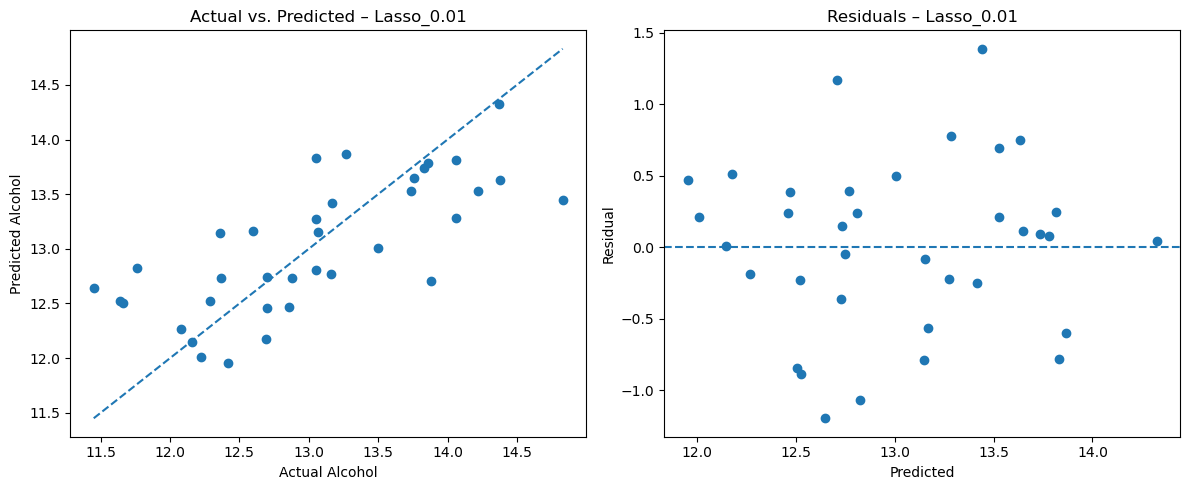

In [15]:
best_name = comparison_df.iloc[0]["Model"]
best_model = fitted[best_name]
print("Best model:", best_name)

best_test_pred = best_model.predict(X_test_scaled)
best_resid = y_test - best_test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, best_test_pred)
lo, hi = min(y_test.min(), best_test_pred.min()), max(y_test.max(), best_test_pred.max())
axes[0].plot([lo, hi], [lo, hi], linestyle="--")
axes[0].set_xlabel("Actual Alcohol")
axes[0].set_ylabel("Predicted Alcohol")
axes[0].set_title(f"Actual vs. Predicted – {best_name}")

axes[1].scatter(best_test_pred, best_resid)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")
axes[1].set_title(f"Residuals – {best_name}")

plt.tight_layout()
plt.show()

## 10. Lasso Feature Selection

In [16]:
example_index = 0
x_example = X_test_scaled[example_index].reshape(1, -1)
true_val = y_test[example_index]
pred_val = best_model.predict(x_example)[0]

print(f"True alcohol:      {true_val:.4f}")
print(f"Predicted alcohol: {pred_val:.4f}")
print(f"Absolute error:    {abs(true_val - pred_val):.4f}")

True alcohol:      12.3600
Predicted alcohol: 13.1469
Absolute error:    0.7869
